<a href="https://colab.research.google.com/github/antonDinkov/AI_integrationsForDev/blob/main/editWithGeminiOnlyInfografica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install -q google-genai

In [ ]:
from google import genai
from google.colab import userdata
from pprint import pprint
from IPython.display import Image, display, Markdown
from PIL import Image as img
import base64


api_key = userdata.get("Gemini_API_Key")
client = genai.Client(api_key=api_key)

In [ ]:
def print_edit_image(response, filename="edited_image.png"):
    print(f"Response is: {response.id}")
    print(f"Input tokens: {response.usage.total_input_tokens}; Output tokens: {response.usage.total_output_tokens}")

    if response.output_text:
        display(Markdown(f"### 💬 Text response\n{response.output_text}"))

    if response.output_image:
        b64_string = response.output_image.data
        image_bytes = base64.b64decode(b64_string)

        display(Markdown("### 🖼 Edited Image"))
        display(Image(data=image_bytes))

        with open(filename, "wb") as f:
            f.write(image_bytes)

        print(f"Saved as {filename}")


In [139]:
generate_portrait_prompt = """Generate a clean, flat-design infographic about the benefits of learning programming.
Use large, clearly separated text boxes and simple icons.
At the top, include a big title in Spanish: "Feliz Cumpleaños".
Make sure the text is easy to read and visually distinct from the background."""


In [140]:
interaction = client.interactions.create(
    model="gemini-3.1-flash-lite-image",
    input=generate_portrait_prompt,
)

Response is: v1_ChdvSEJUYXR5UkRkR1VtdGtQM3JLWXlBMBIXb0hCVGF0eVJEZEdVbXRrUDNyS1l5QTA
Input tokens: 63; Output tokens: 1551


### 🖼 Edited Image

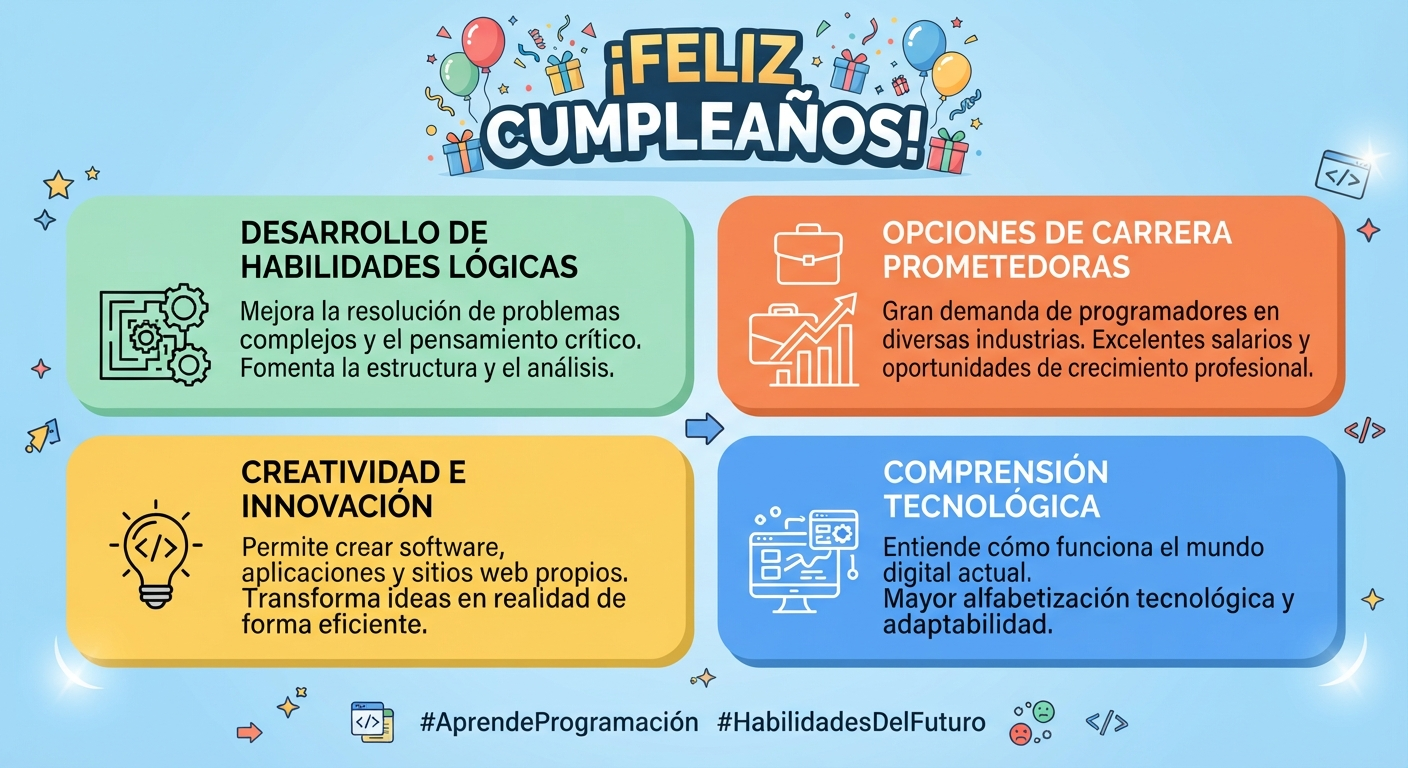

Saved as generated_image.png


In [141]:
print_edit_image(interaction, "generated_image.png")

In [144]:
edit_prompt = """Update this infographic to be in English. Do not change any other elements of the image.
"""

In [146]:
edit_image = client.interactions.create(
    model="gemini-3.1-flash-image",
    input=edit_prompt,
    previous_interaction_id=interaction.id,
    response_format={
        "type": "image",
        "mime_type": "image/jpeg",
        "aspect_ratio": "16:9",
        "image_size": "512"
    },
)


Response is: v1_ChdvSEJUYXR5UkRkR1VtdGtQM3JLWXlBMBIXaW5KVGFxbkNPTHVpcXRzUHB2cUwwQXc
Input tokens: 342; Output tokens: 1469


### 🖼 Edited Image

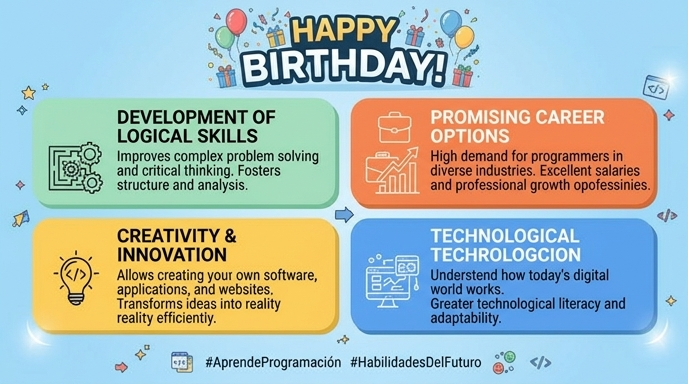

Saved as edited_another_image.png


In [147]:
print_edit_image(edit_image, "edited_another_image.png")